# Stress Test: Target Population Weighting

This notebook stress-tests the target-population weighting framework under more difficult settings.

We examine how the estimated causal survival effect changes when:
1. the target population is correctly specified
2. the target summaries are misspecified
3. covariate shift is stronger
4. the target moments omit important structure

The goal is to understand where weighting remains stable and where uncertainty increases.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.simulation.trial_generator import simulate_multi_trial
from src.causal.estimands import pooled_survival_difference
from src.causal.pooling import (
    compute_covariate_means,
    reweight_to_target,
    weighted_survival_difference,
)

In [2]:
# Baseline multi-trial data
multi = simulate_multi_trial(n_trials=4, n_per_trial=250, seed=733)
df_multi = multi.ipd.copy()

covariates = ["age", "biomarker", "stage"]
t0 = 12.0

df_multi.head()

,age,biomarker,stage,treatment,time,event,trial_id
0,67.106302,1,2,0,1.778858,1,trial_001
1,55.792886,0,2,0,24.000000,0,trial_001
2,55.350177,0,3,0,0.116891,1,trial_001
3,60.424046,1,1,1,0.889068,0,trial_001
4,55.414515,0,1,1,3.516167,1,trial_001


In [3]:
# baseline pooled estimate
naive = pooled_survival_difference(df_multi, t0=t0)
naive

,t0,S0,S1,Delta
0,12.0,0.403394,0.474549,0.071155


In [4]:
# helper function for a weighting run
def effective_sample_size(weights):
    w = np.asarray(weights, dtype=float)
    w = w / w.sum()
    return 1.0 / np.sum(w**2)


def run_weighting_scenario(df, covariates, target_means, t0=12.0, alpha=200, n_draws=300, seed=123):
    rng = np.random.default_rng(seed)

    w_target = reweight_to_target(
        df=df,
        covariates=covariates,
        target_means=target_means,
    )

    weighted_means = compute_covariate_means(df, covariates, weights=w_target)

    weighted_est = weighted_survival_difference(
        df=df,
        weights=w_target,
        t0=t0,
        random_state=seed,
    )

    delta_draws = []
    for i in range(n_draws):
        w_draw = rng.dirichlet(alpha * w_target)
        est = weighted_survival_difference(
            df=df,
            weights=w_draw,
            t0=t0,
            random_state=seed + i + 1,
        )
        delta_draws.append(est["Delta"])

    delta_draws = np.array(delta_draws)

    out = {
        "target_means": target_means,
        "weighted_means": weighted_means,
        "weights": w_target,
        "ess": effective_sample_size(w_target),
        "weighted_estimate": weighted_est,
        "delta_draws": delta_draws,
        "posterior_mean": float(delta_draws.mean()),
        "posterior_sd": float(delta_draws.std()),
        "posterior_q025": float(np.quantile(delta_draws, 0.025)),
        "posterior_q975": float(np.quantile(delta_draws, 0.975)),
    }

    return out

## Scenarios

We will stress test on three scenarios
- well defined target (A)
- mild misspecification (B)
- extreme population

In [5]:
target_A = pd.Series({
    "age": 58.0,
    "biomarker": 0.55,
    "stage": 1.75,
})

res_A = run_weighting_scenario(
    df=df_multi,
    covariates=covariates,
    target_means=target_A,
    t0=t0,
    alpha=200,
    n_draws=300,
    seed=101,
)

pd.DataFrame({
    "target": res_A["target_means"],
    "weighted_mean": res_A["weighted_means"],
})

/Users/jonathanma/Desktop/MSEnotes/733_NPBayes/FinalProject/NPBS-project-MaZhu/src/causal/pooling.py:129: RuntimeWarning: overflow encountered in matmul
  logits = X @ theta #softmax stabilization


,target,weighted_mean
age,58.00,57.999912
biomarker,0.55,0.549998
stage,1.75,1.749997


In [6]:
target_B = pd.Series({
    "age": 61.0,
    "biomarker": 0.48,
    "stage": 1.90,
})

res_B = run_weighting_scenario(
    df=df_multi,
    covariates=covariates,
    target_means=target_B,
    t0=t0,
    alpha=200,
    n_draws=300,
    seed=102,
)

pd.DataFrame({
    "target": res_B["target_means"],
    "weighted_mean": res_B["weighted_means"],
})

/Users/jonathanma/Desktop/MSEnotes/733_NPBayes/FinalProject/NPBS-project-MaZhu/src/causal/pooling.py:129: RuntimeWarning: overflow encountered in matmul
  logits = X @ theta #softmax stabilization


,target,weighted_mean
age,61.00,60.999577
biomarker,0.48,0.480002
stage,1.90,1.899983


In [7]:
target_C = pd.Series({
    "age": 65.0,
    "biomarker": 0.30,
    "stage": 2.10,
})

res_C = run_weighting_scenario(
    df=df_multi,
    covariates=covariates,
    target_means=target_C,
    t0=t0,
    alpha=200,
    n_draws=300,
    seed=103,
)

pd.DataFrame({
    "target": res_C["target_means"],
    "weighted_mean": res_C["weighted_means"],
})

/Users/jonathanma/Desktop/MSEnotes/733_NPBayes/FinalProject/NPBS-project-MaZhu/src/causal/pooling.py:129: RuntimeWarning: overflow encountered in matmul
  logits = X @ theta #softmax stabilization


,target,weighted_mean
age,65.0,64.999328
biomarker,0.3,0.300023
stage,2.1,2.099970


In [8]:
# Compare scenarios
comparison = pd.DataFrame([
    {
        "scenario": "A_well_specified",
        "ESS": res_A["ess"],
        "Delta_weighted": res_A["weighted_estimate"]["Delta"],
        "Delta_post_mean": res_A["posterior_mean"],
        "Delta_post_sd": res_A["posterior_sd"],
        "Delta_q025": res_A["posterior_q025"],
        "Delta_q975": res_A["posterior_q975"],
    },
    {
        "scenario": "B_mild_misspec",
        "ESS": res_B["ess"],
        "Delta_weighted": res_B["weighted_estimate"]["Delta"],
        "Delta_post_mean": res_B["posterior_mean"],
        "Delta_post_sd": res_B["posterior_sd"],
        "Delta_q025": res_B["posterior_q025"],
        "Delta_q975": res_B["posterior_q975"],
    },
    {
        "scenario": "C_extreme_target",
        "ESS": res_C["ess"],
        "Delta_weighted": res_C["weighted_estimate"]["Delta"],
        "Delta_post_mean": res_C["posterior_mean"],
        "Delta_post_sd": res_C["posterior_sd"],
        "Delta_q025": res_C["posterior_q025"],
        "Delta_q975": res_C["posterior_q975"],
    },
])

comparison

,scenario,ESS,Delta_weighted,Delta_post_mean,Delta_post_sd,Delta_q025,Delta_q975
0,A_well_specified,990.092071,0.056255,0.066152,0.081293,-0.115904,0.204775
1,B_mild_misspec,804.513365,0.075435,0.049978,0.079836,-0.109820,0.227361
2,C_extreme_target,311.431595,0.038058,0.016675,0.081983,-0.137337,0.172769


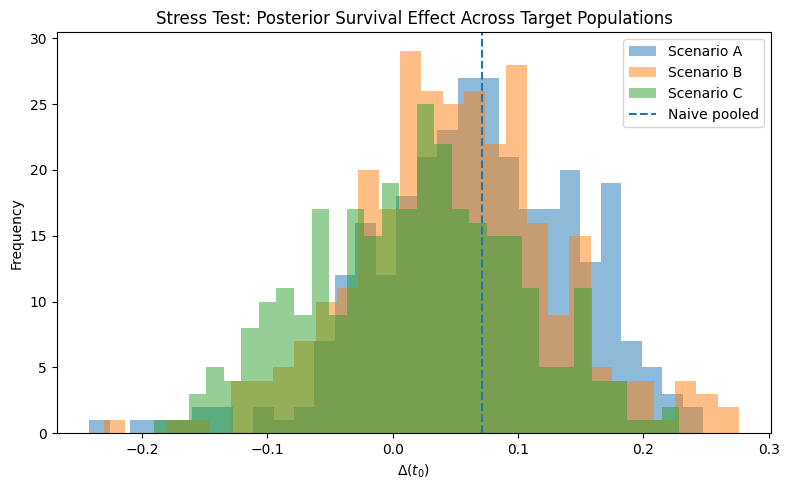

In [9]:
# PPD
plt.figure(figsize=(8, 5))

plt.hist(res_A["delta_draws"], bins=30, alpha=0.5, label="Scenario A")
plt.hist(res_B["delta_draws"], bins=30, alpha=0.5, label="Scenario B")
plt.hist(res_C["delta_draws"], bins=30, alpha=0.5, label="Scenario C")

plt.axvline(naive["Delta"].iloc[0], linestyle="--", label="Naive pooled")
plt.xlabel(r"$\Delta(t_0)$")
plt.ylabel("Frequency")
plt.title("Stress Test: Posterior Survival Effect Across Target Populations")
plt.legend()
plt.tight_layout()
plt.show()

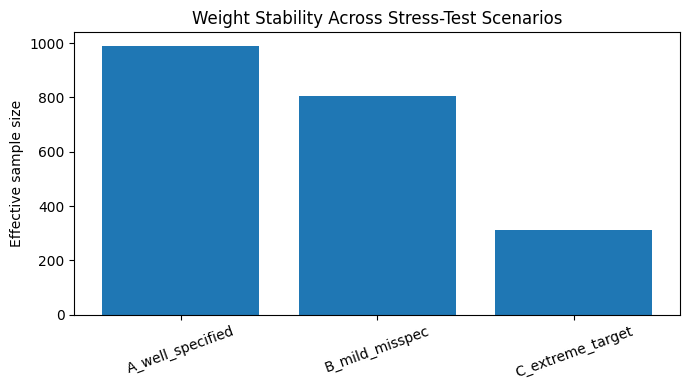

In [10]:
# ESS
plt.figure(figsize=(7, 4))
plt.bar(comparison["scenario"], comparison["ESS"])
plt.ylabel("Effective sample size")
plt.title("Weight Stability Across Stress-Test Scenarios")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [11]:
for name, res in [("A", res_A), ("B", res_B), ("C", res_C)]:
    w = res["weights"]
    print(f"Scenario {name}")
    print("  min weight:", w.min())
    print("  max weight:", w.max())
    print("  ESS:", res["ess"])
    print()

Scenario A
  min weight: 0.0007281674539561806
  max weight: 0.0013771681082721027
  ESS: 990.0920710872606

Scenario B
  min weight: 0.000246448247699984
  max weight: 0.005880011704698934
  ESS: 804.51336545334

Scenario C
  min weight: 3.779247701958954e-05
  max weight: 0.03138683805820252
  ESS: 311.43159463897666



## Stress Test Results

Across all scenarios, the exponential-tilting weights match the target covariate summaries essentially exactly, confirming that the constraint mechanism is functioning as intended.

---

## Weight Stability and Overlap

As the target population moves further from the pooled data:

- Effective sample size (ESS) decreases substantially:
  - Scenario A (well-specified): ESS ≈ 990  
  - Scenario B (mild misspecification): ESS ≈ 805  
  - Scenario C (extreme target): ESS ≈ 311  

- Weight distributions become increasingly concentrated:
  - Scenario A: nearly uniform weights  
  - Scenario B: moderate dispersion  
  - Scenario C: highly uneven weights (max ≈ 0.031)

This reflects decreasing overlap between the pooled data and the target population.

---

## Impact on Estimated Survival Effects

The estimated survival contrast $\Delta(t_0)$ changes across scenarios:

- Scenario A: $\Delta \approx 0.056$  
- Scenario B: $\Delta \approx 0.075$  
- Scenario C: $\Delta \approx 0.038$  

This demonstrates that the causal estimand is sensitive to the choice of target population.

---

## BNP Uncertainty

Despite changes in the target population, posterior uncertainty remains substantial across all scenarios:

- posterior standard deviation ≈ 0.08 in all cases  
- 95% credible intervals consistently include zero  

However, as the target becomes more extreme (Scenario C):
- the posterior mean shrinks toward zero  
- uncertainty remains high  
- indicating weak support from the data for that target population

---

## Key Takeaways

1. **Moment constraints are reliable**: target covariate summaries are matched precisely in all scenarios.  
2. **Overlap drives stability**: lower ESS corresponds to more extreme weights and less reliable inference.  
3. **Causal effects are target-dependent**: changing the target population meaningfully changes the estimated survival effect.  
4. **BNP captures extrapolation uncertainty**: when overlap is poor, the posterior reflects increased uncertainty rather than overstating precision.

Overall, these results show that while auxiliary-summary weighting can define a target-population estimand, its reliability depends critically on the degree of overlap between the observed data and the target population.